# Evaluación del modelo de xG

## 1. ¿Qué esta evaluando?

El **expected goals (xG)** asigna a cada ocasión una probabilidad de terminar en gol según sus características. La suma de esas probabilidades resume cuánto peligro produjo un equipo; no intenta reconstruir exactamente el marcador.

- **xG predicho:** expectativa ofensiva generada por el modelo antes del partido.
- **xG observado:** calidad acumulada de las ocasiones que realmente se produjeron.
- **Goles observados:** resultado final de esas ocasiones, más sensible a la definición y al rendimiento del portero.

In [1]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings("ignore", category=UserWarning)

BLUE = "#2563EB"
BLUE_LIGHT = "#BFDBFE"
GOLD = "#D89B19"
GOLD_LIGHT = "#FDE7A9"
INK = "#1F2937"
MUTED = "#6B7280"
GRID = "#E5E7EB"
PAPER = "#FCFCFA"
GREY = "#9CA3AF"

plt.rcParams.update({
    "figure.facecolor": PAPER,
    "axes.facecolor": PAPER,
    "axes.edgecolor": GRID,
    "axes.labelcolor": INK,
    "text.color": INK,
    "xtick.color": MUTED,
    "ytick.color": MUTED,
    "font.size": 11.5,
    "axes.titleweight": "bold",
})


def clean_axes(ax, grid_axis="y", keep_left=True, keep_bottom=True):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(keep_left)
    ax.spines["bottom"].set_visible(keep_bottom)
    ax.grid(axis=grid_axis, color=GRID, linewidth=0.8, alpha=0.8)
    ax.set_axisbelow(True)


def finish_chart(fig, subtitle, y=0.93):
    fig.text(0.06, y, subtitle, fontsize=10.3, color=MUTED, ha="left")
    fig.text(0.975, 0.975, "✦", fontsize=17, color=GOLD, ha="right", va="top")


data_candidates = [Path("../02_data"), Path("02_data")]
DATA_DIR = next((path for path in data_candidates if path.exists()), None)
if DATA_DIR is None:
    raise FileNotFoundError("No se encontró la carpeta 02_data")

SOURCE_PATH = DATA_DIR / "predictions.xlsx"
raw_predictions = pd.read_excel(SOURCE_PATH)

required_columns = [
    "match_id", "home_team", "away_team", "match_date", "league",
    "proj_home_xg", "proj_away_xg", "home_xg", "away_xg",
    "home_goals", "away_goals",
]
missing_columns = set(required_columns) - set(raw_predictions.columns)
assert not missing_columns, f"Faltan columnas requeridas: {sorted(missing_columns)}"

predictions = raw_predictions[required_columns].copy()
predictions["match_date"] = pd.to_datetime(predictions["match_date"])
complete_predictions = predictions.dropna().copy()

assert raw_predictions["match_id"].is_unique
assert complete_predictions["match_id"].is_unique
assert complete_predictions[required_columns].notna().all().all()
assert (complete_predictions[["proj_home_xg", "proj_away_xg", "home_xg", "away_xg"]] >= 0).all().all()
assert (complete_predictions[["home_goals", "away_goals"]] >= 0).all().all()

coverage = pd.DataFrame({
    "Indicador": [
        "Partidos en el archivo",
        "Partidos completos",
        "Partidos excluidos por xG faltante",
        "Predicciones equipo-partido",
        "Ligas",
        "Periodo",
    ],
    "Valor": [
        f"{len(raw_predictions):,}",
        f"{len(complete_predictions):,}",
        f"{len(raw_predictions) - len(complete_predictions):,}",
        f"{2 * len(complete_predictions):,}",
        f"{complete_predictions['league'].nunique():,}",
        f"{complete_predictions['match_date'].min():%d/%m/%Y} – {complete_predictions['match_date'].max():%d/%m/%Y}",
    ],
})

display(
    coverage.style
    .hide(axis="index")
    .set_properties(**{"text-align": "left", "padding": "7px 14px"})
    .set_table_styles([
        {"selector": "th", "props": [("background-color", BLUE), ("color", "white"), ("text-align", "left")]},
        {"selector": "caption", "props": [("caption-side", "top"), ("font-size", "16px"), ("font-weight", "bold"), ("color", INK)]},
    ])
    .set_caption("Cobertura de la evaluación")
)

Indicador,Valor
Partidos en el archivo,485
Partidos completos,476
Partidos excluidos por xG faltante,9
Predicciones equipo-partido,952
Ligas,8
Periodo,03/01/2025 – 27/04/2025


La comparación se limita a los partidos que contienen predicción, xG observado y marcador para ambos equipos. Los nueve encuentros sin xG observado se conservan en el archivo fuente, pero no entran en las métricas.

## 2. Diez partidos antes de mirar los promedios

Una métrica resume cientos de predicciones, pero no muestra cómo se ve un partido concreto. Las siguientes diez filas se sortean con una semilla fija (`42`): son reproducibles y no fueron elegidas por ser especialmente buenas o malas.

In [2]:
EXAMPLE_SEED = 42

example_matches = (
    complete_predictions
    .sample(n=10, random_state=EXAMPLE_SEED)
    .sort_values(["match_date", "match_id"])
    .copy()
)
example_matches["mean_abs_xg_error"] = (
    (example_matches["proj_home_xg"] - example_matches["home_xg"]).abs()
    + (example_matches["proj_away_xg"] - example_matches["away_xg"]).abs()
) / 2

example_table = pd.DataFrame({
    "Fecha": example_matches["match_date"].dt.strftime("%d/%m/%Y"),
    "Partido": example_matches["home_team"] + " – " + example_matches["away_team"],
    "Liga": example_matches["league"],
    "xG predicho": example_matches.apply(lambda row: f"{row['proj_home_xg']:.2f} – {row['proj_away_xg']:.2f}", axis=1),
    "xG observado": example_matches.apply(lambda row: f"{row['home_xg']:.2f} – {row['away_xg']:.2f}", axis=1),
    "Marcador": example_matches.apply(lambda row: f"{int(row['home_goals'])} – {int(row['away_goals'])}", axis=1),
    "Error medio xG": example_matches["mean_abs_xg_error"],
})

display(
    example_table.style
    .hide(axis="index")
    .format({"Error medio xG": "{:.3f}"})
    .set_properties(**{"padding": "6px 9px", "text-align": "left"})
    .set_table_styles([
        {"selector": "th", "props": [("background-color", BLUE), ("color", "white"), ("text-align", "left")]},
        {"selector": "tbody tr:nth-child(even)", "props": [("background-color", "#F3F4F6")]},
    ])
)

Fecha,Partido,Liga,xG predicho,xG observado,Marcador,Error medio xG
04/01/2025,Lille – Nantes,Ligue 1,1.41 – 0.60,1.19 – 1.33,1 – 1,0.475
04/01/2025,Benfica – Braga,Primeira Liga,1.80 – 0.93,1.63 – 0.73,1 – 2,0.185
11/01/2025,Alavés – Girona,La Liga,0.85 – 1.59,1.31 – 0.50,0 – 1,0.775
25/01/2025,Como – Atalanta,Serie A,1.35 – 1.67,0.77 – 0.96,1 – 2,0.645
27/01/2025,Genoa – Monza,Serie A,1.26 – 0.82,2.66 – 0.43,2 – 0,0.895
14/02/2025,Boavista – Estrela,Primeira Liga,1.25 – 1.21,0.51 – 0.47,0 – 1,0.740
15/02/2025,Aston Villa – Ipswich Town,Premier League,1.55 – 0.83,2.47 – 0.37,1 – 1,0.690
15/02/2025,Willem II – Groningen,Eredivisie,0.65 – 1.15,1.06 – 1.95,1 – 3,0.605
31/03/2025,Celta Vigo – Las Palmas,La Liga,1.86 – 0.53,0.97 – 0.33,1 – 1,0.545
05/04/2025,Mainz 05 – Holstein Kiel,Bundesliga,1.34 – 1.17,1.86 – 0.95,1 – 1,0.370


El marcador y el xG pueden contar historias distintas. Un equipo puede generar mejores ocasiones y aun así marcar menos: por eso el xG observado es la referencia más directa para evaluar la expectativa ofensiva del modelo.

## 3. Tres comparaciones, tres preguntas

1. **Modelo → xG observado:** ¿anticipa la calidad de las ocasiones que producirá cada equipo?
2. **Modelo → goles:** ¿qué tan cerca queda del resultado final, incluyendo la variación de definición?
3. **xG observado → goles:** ¿qué tan cerca queda la propia medida de ocasiones del marcador? Esta tercera fila funciona como referencia, no como un segundo modelo prepartido.

R² se calcula siempre como `r2_score(valor_observado, estimación)`: no es simétrico y debe leerse junto con MAE y RMSE.

In [3]:
home_observations = complete_predictions.rename(columns={
    "home_team": "team",
    "proj_home_xg": "predicted_xg",
    "home_xg": "observed_xg",
    "home_goals": "observed_goals",
})[["match_id", "match_date", "league", "team", "predicted_xg", "observed_xg", "observed_goals"]].assign(side="Local")

away_observations = complete_predictions.rename(columns={
    "away_team": "team",
    "proj_away_xg": "predicted_xg",
    "away_xg": "observed_xg",
    "away_goals": "observed_goals",
})[["match_id", "match_date", "league", "team", "predicted_xg", "observed_xg", "observed_goals"]].assign(side="Visitante")

team_observations = pd.concat([home_observations, away_observations], ignore_index=True)


def regression_metrics(observed, estimated):
    return {
        "MAE": mean_absolute_error(observed, estimated),
        "RMSE": np.sqrt(mean_squared_error(observed, estimated)),
        "R²": r2_score(observed, estimated),
    }


metric_specs = [
    ("Modelo → xG", team_observations["observed_xg"], team_observations["predicted_xg"]),
    ("Modelo → goles", team_observations["observed_goals"], team_observations["predicted_xg"]),
    ("xG → goles", team_observations["observed_goals"], team_observations["observed_xg"]),
]

metrics = pd.DataFrame(
    [{"Comparación": label, **regression_metrics(observed, estimated)} for label, observed, estimated in metric_specs]
).set_index("Comparación")

display(
    metrics.style
    .format({"MAE": "{:.3f}", "RMSE": "{:.3f}", "R²": "{:.3f}"})
    .set_properties(**{"padding": "7px 18px", "text-align": "center"})
    .set_table_styles([
        {"selector": "th", "props": [("background-color", BLUE), ("color", "white"), ("text-align", "center")]},
        {"selector": "th.row_heading", "props": [("text-align", "left")]},
    ])
)

,MAE,RMSE,R²
Comparación,,,
Modelo → xG,0.598,0.786,0.158
Modelo → goles,0.847,1.090,0.072
xG → goles,0.785,1.010,0.203


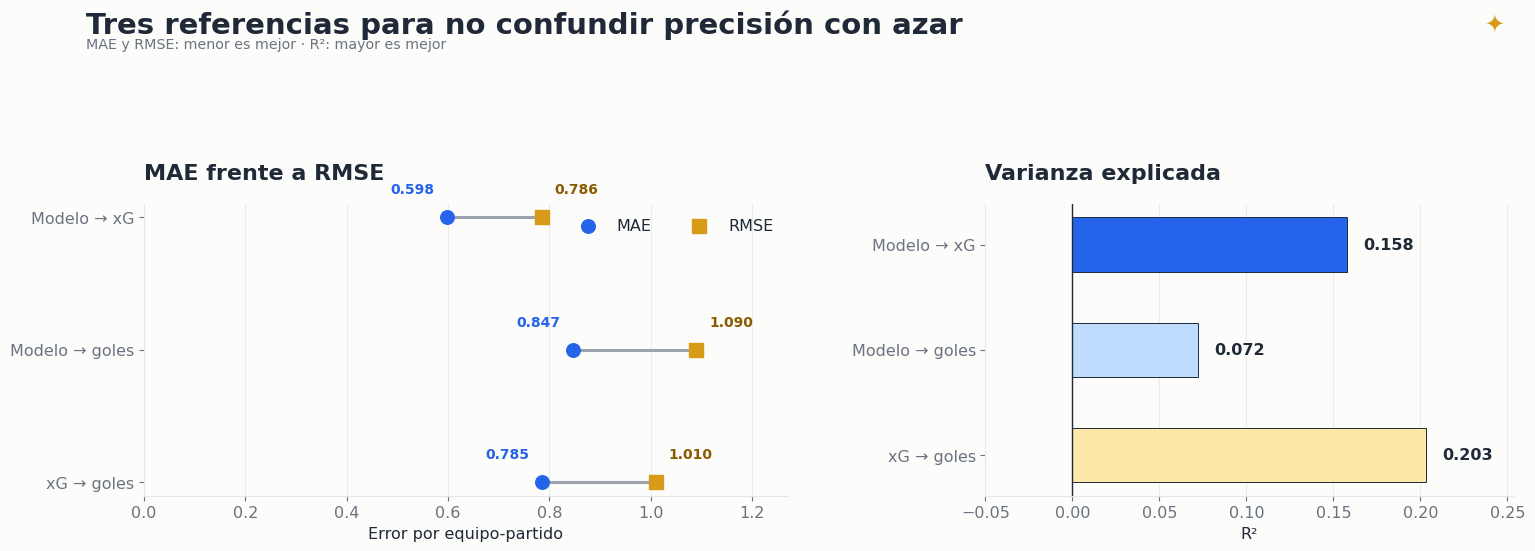

In [4]:
comparison_labels = metrics.index.tolist()
y_positions = np.arange(len(comparison_labels))[::-1]

fig, (ax_error, ax_r2) = plt.subplots(1, 2, figsize=(15.5, 5.6), gridspec_kw={"width_ratios": [1.22, 1]})

for y, label in zip(y_positions, comparison_labels):
    mae = metrics.loc[label, "MAE"]
    rmse = metrics.loc[label, "RMSE"]
    ax_error.plot([mae, rmse], [y, y], color=GREY, linewidth=2.2, zorder=1)
    ax_error.scatter(mae, y, s=95, color=BLUE, marker="o", label="MAE" if y == y_positions[0] else None, zorder=2)
    ax_error.scatter(rmse, y, s=95, color=GOLD, marker="s", label="RMSE" if y == y_positions[0] else None, zorder=2)
    ax_error.text(mae - 0.025, y + 0.18, f"{mae:.3f}", color=BLUE, ha="right", fontsize=10, fontweight="bold")
    ax_error.text(rmse + 0.025, y + 0.18, f"{rmse:.3f}", color="#8A5C00", ha="left", fontsize=10, fontweight="bold")

ax_error.set_yticks(y_positions, comparison_labels)
ax_error.set_xlim(0, metrics["RMSE"].max() + 0.18)
ax_error.set_xlabel("Error por equipo-partido")
ax_error.set_title("MAE frente a RMSE", loc="left", fontsize=16, pad=18)
ax_error.legend(frameon=False, ncol=2, loc="upper right")
clean_axes(ax_error, grid_axis="x")

r2_values = metrics["R²"].to_numpy()
bars = ax_r2.barh(y_positions, r2_values, color=[BLUE, BLUE_LIGHT, GOLD_LIGHT], edgecolor=INK, linewidth=0.7, height=0.52)
ax_r2.axvline(0, color=INK, linewidth=1.0)
for bar, value in zip(bars, r2_values):
    ax_r2.text(value + 0.009, bar.get_y() + bar.get_height() / 2, f"{value:.3f}", va="center", fontweight="bold")

ax_r2.set_yticks(y_positions, comparison_labels)
ax_r2.set_xlim(min(-0.05, r2_values.min() - 0.04), max(0.25, r2_values.max() + 0.05))
ax_r2.set_xlabel("R²")
ax_r2.set_title("Varianza explicada", loc="left", fontsize=16, pad=18)
clean_axes(ax_r2, grid_axis="x")

fig.suptitle("Tres referencias para no confundir precisión con azar", x=0.06, ha="left", fontsize=21, fontweight="bold")
finish_chart(fig, "MAE y RMSE: menor es mejor · R²: mayor es mejor", y=0.91)
plt.tight_layout(rect=(0, 0, 1, 0.82), w_pad=4)
plt.show()

In [5]:
model_xg_mae = metrics.loc["Modelo → xG", "MAE"]
model_goal_mae = metrics.loc["Modelo → goles", "MAE"]
model_xg_rmse = metrics.loc["Modelo → xG", "RMSE"]

display(Markdown(
    f"El modelo queda **{model_goal_mae - model_xg_mae:.3f} unidades más cerca** del xG observado que de los goles finales según MAE. "
    f"Además, su RMSE frente al xG ({model_xg_rmse:.3f}) supera al MAE ({model_xg_mae:.3f}); esa separación indica que algunos errores grandes pesan de forma visible."
))

El modelo queda **0.249 unidades más cerca** del xG observado que de los goles finales según MAE. Además, su RMSE frente al xG (0.786) supera al MAE (0.598); esa separación indica que algunos errores grandes pesan de forma visible.

## 4. xG observado frente a xG predicho

Cada punto representa la expectativa ofensiva de un equipo en un partido. La diagonal negra es la predicción perfecta: un punto **arriba** significa que el modelo subestimó el xG observado; un punto **abajo**, que lo sobreestimó.

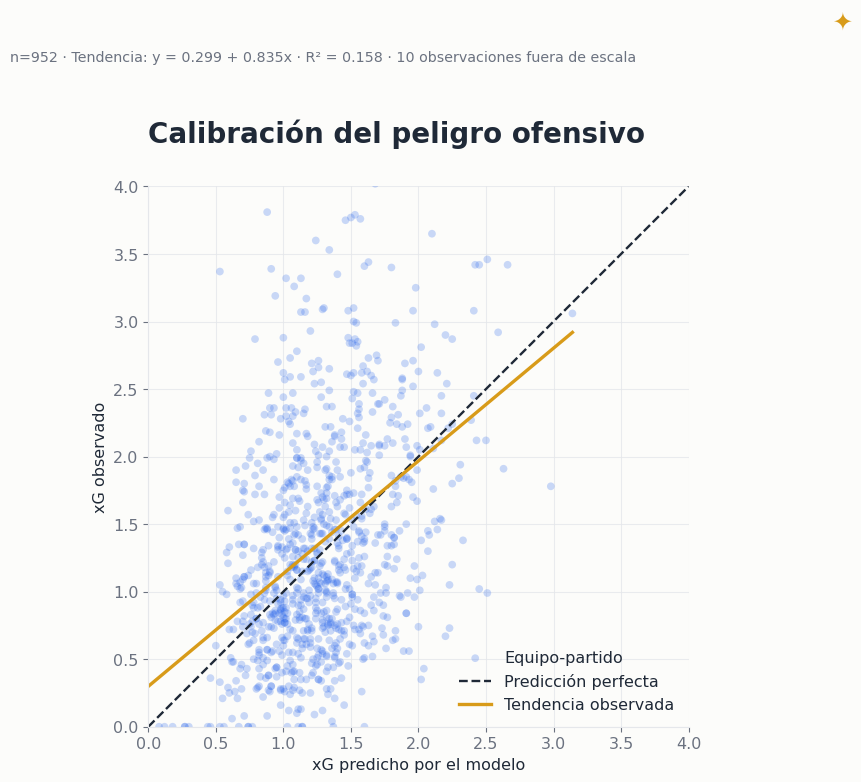

In [6]:
predicted_xg = team_observations["predicted_xg"].to_numpy()
observed_xg = team_observations["observed_xg"].to_numpy()
xg_slope, xg_intercept = np.polyfit(predicted_xg, observed_xg, 1)
xg_r2 = metrics.loc["Modelo → xG", "R²"]

axis_limit = 4.0
out_of_view = int(((predicted_xg > axis_limit) | (observed_xg > axis_limit)).sum())
fit_x = np.linspace(0, predicted_xg.max(), 200)

fig, ax = plt.subplots(figsize=(9.2, 8.0))
ax.scatter(predicted_xg, observed_xg, s=31, color=BLUE, alpha=0.24, edgecolors="none", label="Equipo-partido")
ax.plot([0, axis_limit], [0, axis_limit], color=INK, linestyle="--", linewidth=1.7, label="Predicción perfecta")
ax.plot(fit_x, xg_intercept + xg_slope * fit_x, color=GOLD, linewidth=2.4, label="Tendencia observada")

ax.set_xlim(0, axis_limit)
ax.set_ylim(0, axis_limit)
ax.set_aspect("equal", adjustable="box")
ax.set_xlabel("xG predicho por el modelo")
ax.set_ylabel("xG observado")
ax.set_title("Calibración del peligro ofensivo", loc="left", fontsize=20, pad=32)
ax.legend(frameon=False, loc="lower right")
clean_axes(ax, grid_axis="both")

finish_chart(
    fig,
    f"n={len(team_observations):,} · Tendencia: y = {xg_intercept:.3f} + {xg_slope:.3f}x · R² = {xg_r2:.3f} · {out_of_view} observaciones fuera de escala",
    y=0.91,
)
plt.tight_layout(rect=(0, 0, 1, 0.86))
plt.show()

In [7]:
crossover = xg_intercept / (1 - xg_slope)
display(Markdown(
    f"La tendencia observada tiene pendiente **{xg_slope:.3f}**, menor que la pendiente ideal de 1. "
    f"En promedio cruza la diagonal cerca de **{crossover:.2f} xG**: por debajo de ese nivel tiende a quedar por encima de la predicción y, por encima, la tendencia se aplana. "
    "La dispersión alrededor de ambas líneas recuerda que una predicción individual sigue teniendo incertidumbre considerable."
))

La tendencia observada tiene pendiente **0.835**, menor que la pendiente ideal de 1. En promedio cruza la diagonal cerca de **1.81 xG**: por debajo de ese nivel tiende a quedar por encima de la predicción y, por encima, la tendencia se aplana. La dispersión alrededor de ambas líneas recuerda que una predicción individual sigue teniendo incertidumbre considerable.

## 5. ¿Dónde se equivoca el modelo?

Definimos el residuo como `xG observado − xG predicho`. Un residuo positivo indica subestimación; uno negativo, sobreestimación. El histograma muestra la distribución completa y el segundo panel comprueba si el error cambia con el nivel pronosticado.

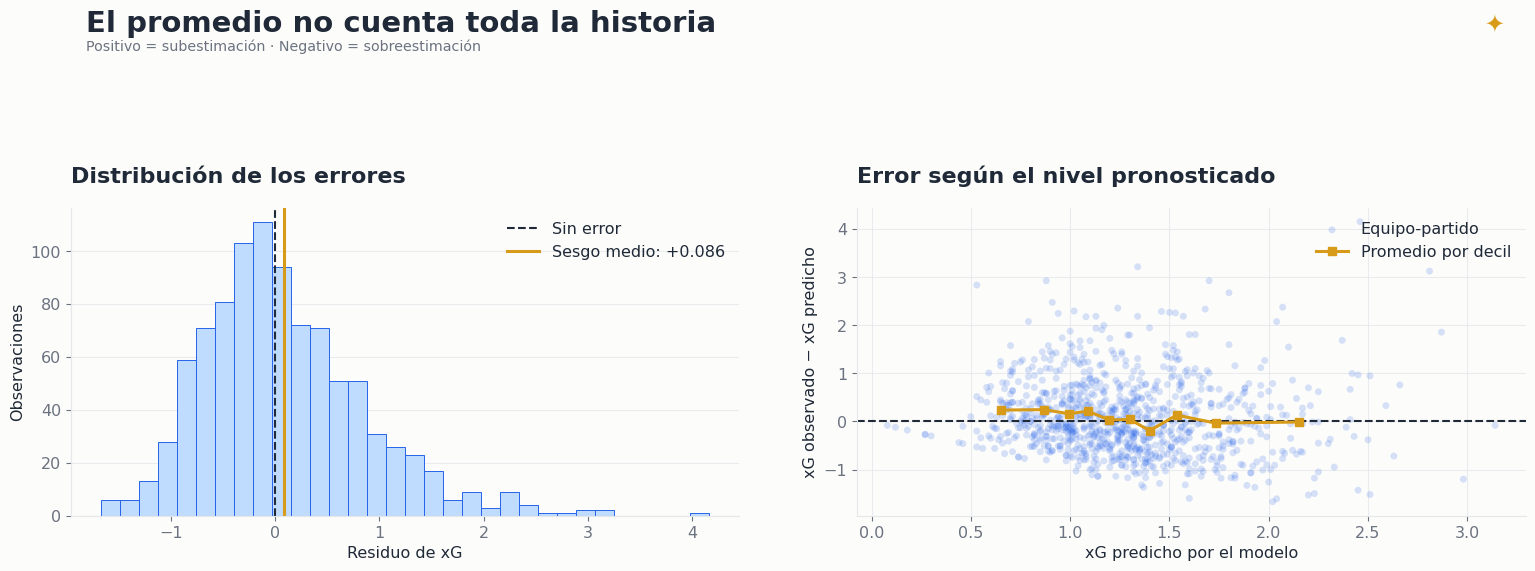

In [8]:
team_observations["xg_residual"] = team_observations["observed_xg"] - team_observations["predicted_xg"]
team_observations["prediction_decile"] = pd.qcut(
    team_observations["predicted_xg"], q=10, duplicates="drop"
)

residual_by_decile = (
    team_observations
    .groupby("prediction_decile", observed=False)
    .agg(
        mean_predicted_xg=("predicted_xg", "mean"),
        mean_residual=("xg_residual", "mean"),
        observations=("match_id", "size"),
    )
    .reset_index(drop=True)
)

mean_residual = team_observations["xg_residual"].mean()

fig, (ax_hist, ax_residual) = plt.subplots(1, 2, figsize=(15.5, 5.8))

ax_hist.hist(team_observations["xg_residual"], bins=32, color=BLUE_LIGHT, edgecolor=BLUE, linewidth=0.7)
ax_hist.axvline(0, color=INK, linestyle="--", linewidth=1.5, label="Sin error")
ax_hist.axvline(mean_residual, color=GOLD, linewidth=2.2, label=f"Sesgo medio: {mean_residual:+.3f}")
ax_hist.set_xlabel("Residuo de xG")
ax_hist.set_ylabel("Observaciones")
ax_hist.set_title("Distribución de los errores", loc="left", fontsize=16, pad=18)
ax_hist.legend(frameon=False)
clean_axes(ax_hist, grid_axis="y")

ax_residual.scatter(
    team_observations["predicted_xg"],
    team_observations["xg_residual"],
    s=25,
    color=BLUE,
    alpha=0.18,
    edgecolors="none",
    label="Equipo-partido",
)
ax_residual.axhline(0, color=INK, linestyle="--", linewidth=1.5)
ax_residual.plot(
    residual_by_decile["mean_predicted_xg"],
    residual_by_decile["mean_residual"],
    color=GOLD,
    marker="s",
    markersize=6,
    linewidth=2.2,
    label="Promedio por decil",
)
ax_residual.set_xlabel("xG predicho por el modelo")
ax_residual.set_ylabel("xG observado − xG predicho")
ax_residual.set_title("Error según el nivel pronosticado", loc="left", fontsize=16, pad=18)
ax_residual.legend(frameon=False, loc="upper right")
clean_axes(ax_residual, grid_axis="both")

fig.suptitle("El promedio no cuenta toda la historia", x=0.06, ha="left", fontsize=21, fontweight="bold")
finish_chart(fig, "Positivo = subestimación · Negativo = sobreestimación", y=0.91)
plt.tight_layout(rect=(0, 0, 1, 0.82), w_pad=4)
plt.show()

In [9]:
display(Markdown(
    f"El residuo medio es **{mean_residual:+.3f} xG**: en el conjunto completo, el modelo subestima ligeramente el xG observado. "
    "La línea por deciles es más útil que una sola media porque permite ver si ese sesgo se concentra en predicciones bajas o altas."
))

El residuo medio es **+0.086 xG**: en el conjunto completo, el modelo subestima ligeramente el xG observado. La línea por deciles es más útil que una sola media porque permite ver si ese sesgo se concentra en predicciones bajas o altas.

## 6. Goles observados frente a xG predicho

Los goles solo pueden tomar valores enteros, por lo que los puntos forman franjas horizontales. Para hacer visible la calibración sin esconder los partidos individuales, superponemos el promedio de goles dentro de diez grupos de igual tamaño ordenados por xG predicho.

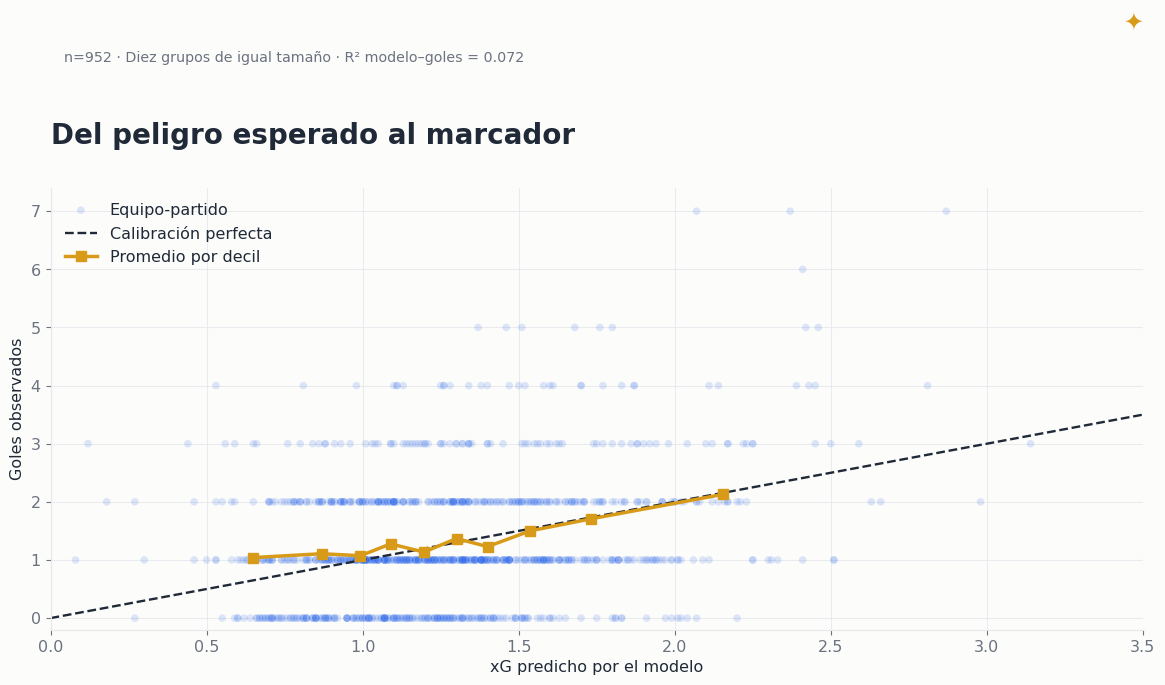

In [10]:
team_observations["goal_calibration_decile"] = pd.qcut(
    team_observations["predicted_xg"], q=10, duplicates="drop"
)
goal_calibration = (
    team_observations
    .groupby("goal_calibration_decile", observed=False)
    .agg(
        mean_predicted_xg=("predicted_xg", "mean"),
        mean_goals=("observed_goals", "mean"),
        observations=("match_id", "size"),
    )
    .reset_index(drop=True)
)

goal_r2 = metrics.loc["Modelo → goles", "R²"]
x_limit = np.ceil(team_observations["predicted_xg"].max() * 2) / 2
y_limit = int(team_observations["observed_goals"].max()) + 0.4

fig, ax = plt.subplots(figsize=(11.8, 7.0))
ax.scatter(
    team_observations["predicted_xg"],
    team_observations["observed_goals"],
    s=30,
    color=BLUE,
    alpha=0.15,
    edgecolors="none",
    label="Equipo-partido",
)
ax.plot([0, x_limit], [0, x_limit], color=INK, linestyle="--", linewidth=1.7, label="Calibración perfecta")
ax.plot(
    goal_calibration["mean_predicted_xg"],
    goal_calibration["mean_goals"],
    color=GOLD,
    marker="s",
    markersize=7,
    linewidth=2.5,
    label="Promedio por decil",
)

ax.set_xlim(0, x_limit)
ax.set_ylim(-0.2, y_limit)
ax.set_xlabel("xG predicho por el modelo")
ax.set_ylabel("Goles observados")
ax.set_title("Del peligro esperado al marcador", loc="left", fontsize=20, pad=32)
ax.legend(frameon=False, loc="upper left")
clean_axes(ax, grid_axis="both")

finish_chart(fig, f"n={len(team_observations):,} · Diez grupos de igual tamaño · R² modelo–goles = {goal_r2:.3f}", y=0.90)
plt.tight_layout(rect=(0, 0, 1, 0.84))
plt.show()

La curva dorada permite leer la relación promedio sin fingir que cada partido debería caer exactamente sobre la diagonal. Los puntos permanecen visibles para mostrar cuánto puede variar el marcador incluso entre equipos con expectativas parecidas.

## 7. Qué nos llevamos

- El modelo se acerca más al **xG observado** que a los goles: MAE de **0.598** frente a **0.847**.
- La comparación modelo–xG alcanza R² **0.158**; frente a goles baja a **0.072**, consistente con el ruido adicional del marcador.
- El propio xG observado tampoco reproduce perfectamente los goles: su MAE es **0.785** y su R² **0.203**. Esta referencia pone en contexto el límite de una predicción prepartido.
- RMSE supera al MAE en las tres comparaciones, señal de que una parte del error proviene de casos grandes y no de una desviación uniforme.
- La pendiente de calibración modelo–xG es menor que 1 y el residuo medio es ligeramente positivo; conviene revisar la compresión de predicciones bajas y altas antes de interpretar solo el promedio.

El siguiente notebook transforma estas distribuciones de goles esperados en probabilidades de mercado; aquí dejamos aislada la calidad de la predicción base.

## Checks de reproducibilidad

- Fuente congelada: `02_data/predictions.xlsx`, hoja `Sheet1`.
- Muestra original: 485 partidos; muestra completa: 476 partidos y 952 observaciones equipo-partido.
- Exclusión: nueve partidos sin xG observado para uno o ambos equipos.
- Ejemplos: diez partidos sin reemplazo con `random_state=42`.
- Métricas: `sklearn.metrics`, con el valor observado como `y_true` y la estimación como `y_pred`.
- Calibración y residuos: diez grupos de igual frecuencia calculados con `pandas.qcut`.
- El notebook no abre conexiones SQL, no utiliza credenciales y no necesita red.

In [11]:
expected_metrics = pd.DataFrame(
    {
        "MAE": [0.598, 0.847, 0.785],
        "RMSE": [0.786, 1.090, 1.010],
        "R²": [0.158, 0.072, 0.203],
    },
    index=["Modelo → xG", "Modelo → goles", "xG → goles"],
)

assert len(raw_predictions) == 485
assert len(complete_predictions) == 476
assert len(team_observations) == 952
assert len(example_matches) == 10
assert example_matches["match_id"].nunique() == 10
assert len(residual_by_decile) == 10
assert len(goal_calibration) == 10
assert np.allclose(metrics.loc[expected_metrics.index, expected_metrics.columns], expected_metrics, atol=5e-4)

print("✓ Datos, muestra aleatoria, métricas y grupos de calibración verificados.")

✓ Datos, muestra aleatoria, métricas y grupos de calibración verificados.
